# Advanced Phishing Email Detection with Naive Bayes
This notebook builds on the existing spam detection system to classify emails into **Ham**, **Spam**, or **Phishing** using **Naive Bayes + TF-IDF**.

This uses **7 data sources** (~560k emails) with structural and phishing-specific features.

In [1]:
# Core libraries for data handling, plotting, and text preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os
import time
import json
import joblib
# Machine learning tools for the Naive Bayes baseline
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load and Normalize All 7 Datasets
We combine multiple sources to train a robust 3-class classifier:
- **0** = Ham (legitimate email)
- **1** = Spam (general unwanted email)
- **2** = Phishing (malicious/fraudulent email)

In [2]:
DATA_DIR = '../Dataset'

def load_existing():
    df = pd.read_csv(os.path.join(DATA_DIR, 'spam_Emails_data.csv'), encoding='latin-1')
    df['label_num'] = df['label'].map({'Ham': 0, 'Spam': 1})
    df['source'] = 'existing'
    return df[['text', 'label_num', 'source']].copy()

def load_enron():
    df = pd.read_csv(os.path.join(DATA_DIR, 'enron_spam.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df['source'] = 'enron'
    return df[['text', 'label_num', 'source']].copy()

def load_spamassassin():
    df = pd.read_csv(os.path.join(DATA_DIR, 'spamassassin.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df.rename(columns={'data': 'text'}, inplace=True)
    df['source'] = 'spamassassin'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_liu():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_liu.csv'))
    df['label_num'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 2})
    df.rename(columns={'Email Text': 'text'}, inplace=True)
    df['source'] = 'phishing_liu'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_7ds():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_7ds.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df['source'] = 'phishing_7ds'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_v2():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_v2.csv'))
    # 0=benign(ham), 1=spam, 2=phishing, 3=malware -> treat malware as phishing
    df['label_num'] = df['label'].map({0: 0, 1: 1, 2: 2, 3: 2})
    df.rename(columns={'content': 'text'}, inplace=True)
    df['source'] = 'phishing_v2'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_rbn():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_rbn.csv'))
    df['label_num'] = df['email_type'].map({'safe email': 0, 'phishing email': 2})
    df['source'] = 'phishing_rbn'
    return df[['text', 'label_num', 'source']].copy()

In [3]:
# Load all datasets and display their sizes and label distributions
loaders = [
    ('Existing (193k)', load_existing),
    ('Enron', load_enron),
    ('SpamAssassin', load_spamassassin),
    ('Phishing Liu', load_phishing_liu),
    ('Phishing 7DS', load_phishing_7ds),
    ('Phishing v2.0', load_phishing_v2),
    ('Phishing Rabin', load_phishing_rbn),
]

all_dfs = []
for name, loader in loaders:
    df = loader()
    dist = dict(df['label_num'].value_counts().sort_index())
    print(f'{name:22s} -> {len(df):>6d} rows, labels: {dist}')
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
print(f'\nTOTAL: {len(combined):,} rows')
print(f'Label distribution: {dict(combined["label_num"].value_counts().sort_index())}')

Existing (193k)        -> 193852 rows, labels: {0: np.int64(102160), 1: np.int64(91692)}
Enron                  ->  31716 rows, labels: {0: np.int64(15553), 1: np.int64(16163)}
SpamAssassin           ->   6046 rows, labels: {0: np.int64(4150), 1: np.int64(1896)}
Phishing Liu           ->  18650 rows, labels: {0: np.int64(11322), 2: np.int64(7328)}
Phishing 7DS           -> 162413 rows, labels: {0: np.int64(86951), 1: np.int64(75462)}
Phishing v2.0          -> 120000 rows, labels: {0: np.int64(6809), 1: np.int64(6684), 2: np.int64(106507)}
Phishing Rabin         ->  26946 rows, labels: {0: np.int64(13473), 2: np.int64(13473)}

TOTAL: 559,623 rows
Label distribution: {0: np.int64(240418), 1: np.int64(191897), 2: np.int64(127308)}


In [4]:
# Drop any rows with missing text
before = len(combined)
combined = combined.dropna(subset=['text']).reset_index(drop=True)
print('Dropped', before - len(combined), 'rows with missing text')
print('Final dataset shape:', combined.shape)

combined.head()

Dropped 72 rows with missing text
Final dataset shape: (559551, 3)


,text,label_num,source
0,viiiiiiagraaaa\nonly for the ones that want to...,1,existing
1,got ice thought look az original message ice o...,0,existing
2,yo ur wom an ne eds an escapenumber in ch ma n...,1,existing
3,start increasing your odds of success & live s...,1,existing
4,author jra date escapenumber escapenumber esca...,0,existing


## 2. Text Preprocessing
Clean the email text by removing HTML, links, emails, non-alphabetic characters, and standardizing whitespace.

In [5]:
# Clean the raw email text for the Naive Bayes model
# This removes HTML tags, links, emails, numbers, punctuation, stop words, and abnormally long tokens
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)
    text = re.sub(r'\d+', ' numbertoken ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [word for word in text.split() if word not in ENGLISH_STOP_WORDS and len(word) <= 50]
    return ' '.join(tokens)

print('Cleaning email text...')
t0 = time.time()
combined['clean_text'] = combined['text'].apply(clean_text)
print(f'Cleaned {len(combined):,} texts in {time.time()-t0:.1f}s')

Cleaning email text...
Cleaned 559,551 texts in 80.2s


In [6]:
# Show sample cleaned text
combined[['label_num', 'text', 'clean_text']].head()

,label_num,text,clean_text
0,1,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa ones want make scream prodigy s...
1,0,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne eds escapenumber ch ma n b e th m...
3,1,start increasing your odds of success & live s...,start increasing odds success live sexually he...
4,0,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


### Rule-Based Phishing Features
Extract phishing-specific signals that help distinguish phishing from regular spam, such as brand impersonation, urgency language, typosquatting, and suspicious URL patterns.

In [7]:
# Build a simple phishing score from several warning signs instead of one keyword only
urgent_patterns = [
    r'urgent', r'immediately', r'action required', r'account suspended',
    r'verify your account', r'confirm your identity', r'limited time'
]

sensitive_patterns = [
    r'password', r'otp', r'login', r'bank account',
    r'credit card', r'ssn', r'social security'
]

brand_patterns = [
    r'paypal', r'microsoft', r'google', r'apple',
    r'bank', r'netflix', r'amazon'
]

THREAT_WORDS = ['terminated', 'charged', 'fee', 'penalty', 'legal action', 'lawsuit']
CREDENTIAL_PHRASES = ['verify your password', 'confirm your account', 'login details',
                      'update your billing', 'your account has been']
SUSPICIOUS_DOMAIN_PATTERNS = ['secure-', 'account-', 'verify-', 'login-', 'update-', 'confirm-']

def extract_all_features(text):
    """Extract structural and phishing-specific features from raw email text."""
    text = str(text) if not isinstance(text, str) else text
    clean_lower = text.lower()
    words = clean_lower.split()
    urls = re.findall(r'http[s]?://\S+', text)
    
    return {
        'text_length': len(text),
        'word_count': len(words),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'capital_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'url_count': len(urls),
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'dollar_count': text.count('$'),
        'has_free': 1 if 'free' in clean_lower else 0,
        'has_urgent': 1 if any(re.search(p, clean_lower) for p in urgent_patterns) else 0,
        'brand_count': sum(clean_lower.count(b) for b in ['paypal', 'amazon', 'netflix', 'apple', 'google', 'microsoft', 'facebook']),
        'urgency_score': sum(1 for p in urgent_patterns if re.search(p, clean_lower)),
        'threat_score': sum(1 for w in THREAT_WORDS if w in clean_lower),
        'credential_request': sum(1 for p in CREDENTIAL_PHRASES if p in clean_lower),
        'typosquatting': len(re.findall(r'payp[a0]l|g00gle|faceb00k|micr0s0ft', clean_lower)),
        'suspicious_urls': sum(
            1 for u in urls
            for pat in SUSPICIOUS_DOMAIN_PATTERNS if pat in u.lower()
        ),
    }

print('Extracting features...')
t0 = time.time()
feature_dicts = combined['text'].apply(extract_all_features)
feature_df = pd.DataFrame(feature_dicts.tolist())
combined = pd.concat([combined, feature_df], axis=1)
print(f'Extracted {len(feature_df.columns)} features in {time.time()-t0:.1f}s')
print('Features:', list(feature_df.columns))

Extracting features...
Extracted 16 features in 55.9s
Features: ['text_length', 'word_count', 'avg_word_length', 'capital_ratio', 'url_count', 'exclamation_count', 'question_count', 'dollar_count', 'has_free', 'has_urgent', 'brand_count', 'urgency_score', 'threat_score', 'credential_request', 'typosquatting', 'suspicious_urls']


In [8]:
# Show average feature values per class to see what distinguishes phishing from spam
combined.groupby('label_num')[list(feature_df.columns)].mean().round(2)

,text_length,word_count,avg_word_length,capital_ratio,url_count,exclamation_count,question_count,dollar_count,has_free,has_urgent,brand_count,urgency_score,threat_score,credential_request,typosquatting,suspicious_urls
label_num,,,,,,,,,,,,,,,,
0,2232.75,359.79,5.34,0.02,0.68,0.65,1.11,0.84,0.12,0.04,0.13,0.04,0.13,0.0,0.00,0.0
1,1352.29,204.77,6.57,0.03,0.59,1.08,0.95,0.96,0.15,0.05,0.16,0.06,0.15,0.0,0.02,0.0
2,185.85,26.64,31.69,0.01,0.95,0.27,0.44,0.14,0.02,0.01,0.03,0.01,0.01,0.0,0.00,0.0


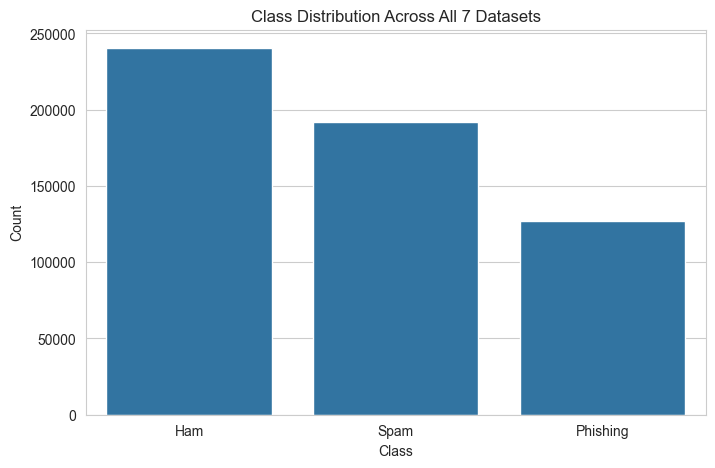

In [9]:
# Plot the class distribution
label_names = {0: 'Ham', 1: 'Spam', 2: 'Phishing'}
combined['label_name'] = combined['label_num'].map(label_names)
plt.figure(figsize=(8, 5))
sns.countplot(x='label_name', data=combined, order=['Ham', 'Spam', 'Phishing'])
plt.title('Class Distribution Across All 7 Datasets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 3. Train/Test Split
We split the data before training so we can test the model on unseen emails. stratify=y keeps the class ratio similar in both sets.

In [10]:
# Use the cleaned text for the Naive Bayes baseline
# Split the data into training and testing sets
FEATURE_COLS = [c for c in feature_df.columns]
X_text = combined['clean_text']
y = combined['label_num']
X_feat = combined[FEATURE_COLS].values.astype(np.float32)

X_train_text, X_test_text, y_train, y_test, X_train_feat, X_test_feat = train_test_split(
    X_text, y, X_feat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dist_train = {int(k): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))}
dist_test = {int(k): int(v) for k, v in zip(*np.unique(y_test, return_counts=True))}
print('Training samples:', len(X_train_text), ' distribution:', dist_train)
print('Testing samples:', len(X_test_text), '  distribution:', dist_test)

Training samples: 447640  distribution: {0: 192333, 1: 153473, 2: 101834}
Testing samples: 111911   distribution: {0: 48084, 1: 38369, 2: 25458}


## 4. Naive Bayes Model
This baseline uses **TF-IDF** to turn text into numeric features and **Multinomial Naive Bayes** to classify each email into ham, spam, or phishing.

In [11]:
TRAIN_NAIVE_BAYES = False
# Set to False after first training to load saved model

In [12]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Train a new Naive Bayes model or load a saved one
if TRAIN_NAIVE_BAYES:
    # Convert text into TF-IDF features using single words and short phrases
    print('Training TF-IDF vectorizer...')
    t0 = time.time()
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )
    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_test_tfidf = tfidf.transform(X_test_text)
    print(f'  TF-IDF done: {X_train_tfidf.shape} in {time.time()-t0:.1f}s')
    
    # Scale engineered features and concatenate with TF-IDF
    print('Scaling engineered features...')
    scaler = MinMaxScaler()
    X_train_feat_scaled = scaler.fit_transform(X_train_feat)
    X_test_feat_scaled = scaler.transform(X_test_feat)
    X_train_combined = hstack([X_train_tfidf, X_train_feat_scaled])
    X_test_combined = hstack([X_test_tfidf, X_test_feat_scaled])
    print(f'  Combined shape: {X_train_combined.shape}')
    
    # Class weights to penalize misclassifying the minority phishing class more
    class_counts = np.bincount(y_train.astype(int))
    class_weights = {i: len(y_train) / (len(class_counts) * count) for i, count in enumerate(class_counts)}
    print(f'  Class weights: {class_weights}')
    sample_weights = np.array([class_weights[y] for y in y_train])
    
    # Train the classifier on the combined features
    nb_model = MultinomialNB(alpha=0.5)
    nb_model.fit(X_train_combined, y_train, sample_weight=sample_weights)
    
    # Save the trained model, vectorizer, and scaler for later reuse
    joblib.dump(nb_model, '../naive_bayes_3class_model.pkl')
    joblib.dump(tfidf, '../tfidf_vectorizer_3class.pkl')
    joblib.dump(scaler, '../feature_scaler_3class.pkl')
    print('Naive Bayes model trained and saved.')
else:
    # Load the model, vectorizer, and scaler from disk
    nb_model = joblib.load('../naive_bayes_3class_model.pkl')
    tfidf = joblib.load('../tfidf_vectorizer_3class.pkl')
    scaler = joblib.load('../feature_scaler_3class.pkl')
    # Transform the test set using the saved TF-IDF vocabulary and scaler
    X_test_tfidf = tfidf.transform(X_test_text)
    X_test_feat_scaled = scaler.transform(X_test_feat)
    X_test_combined = hstack([X_test_tfidf, X_test_feat_scaled])
    print('Saved Naive Bayes model loaded successfully.')

Saved Naive Bayes model loaded successfully.


In [13]:
# Predict labels on the test set using combined TF-IDF + engineered features
nb_preds = nb_model.predict(X_test_combined)

In [14]:
# Evaluate the Naive Bayes model using standard classification metrics
nb_accuracy = accuracy_score(y_test, nb_preds)
nb_precision, nb_recall, nb_f1, _ = precision_recall_fscore_support(y_test, nb_preds, average='weighted')
cm_nb = confusion_matrix(y_test, nb_preds)
print('Naive Bayes Accuracy:', round(nb_accuracy, 4))
print(classification_report(y_test, nb_preds, target_names=['ham', 'spam', 'phishing']))

Naive Bayes Accuracy: 0.97
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99     48084
        spam       0.95      0.96      0.96     38369
    phishing       0.98      0.94      0.96     25458

    accuracy                           0.97    111911
   macro avg       0.97      0.96      0.97    111911
weighted avg       0.97      0.97      0.97    111911



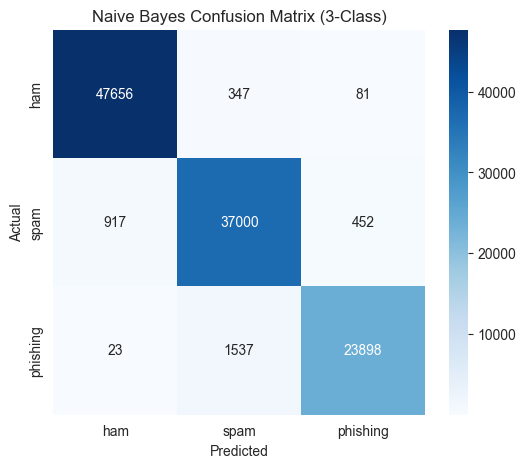

In [15]:
# Plot the confusion matrix to see correct and incorrect classifications
cm_nb = confusion_matrix(y_test, nb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam', 'phishing'],
            yticklabels=['ham', 'spam', 'phishing'])
plt.title('Naive Bayes Confusion Matrix (3-Class)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
# Calculate and display False Positive Rate per class
print('False Positive Rate per class:')
print('=' * 35)
for i, name in enumerate(['Ham', 'Spam', 'Phishing']):
    fp = cm_nb[:, i].sum() - cm_nb[i, i]
    tn = cm_nb.sum() - (cm_nb[i, :].sum() + cm_nb[:, i].sum() - cm_nb[i, i])
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{name:15s} FPR: {fpr*100:.2f}%')

False Positive Rate per class:
Ham             FPR: 1.47%
Spam            FPR: 2.56%
Phishing        FPR: 0.62%


## 4. RoBERTA Model with Phishing Features

RoBERTA is a deep learning NLP model that reads email text and predicts whether it is ham (0 = normal text), spam (1 = junk text), or phishing (2 = malicious/fraudulent email). This implementation combines RoBERTA text embeddings with engineered phishing-specific features (urgency patterns, credential requests, suspicious URLs, etc.) for enhanced detection accuracy.

In [17]:
ROBERTA_SAMPLE_SIZE = 100000

roberta_df = combined.sample(n=min(ROBERTA_SAMPLE_SIZE, len(combined)), random_state=42)

X_roberta = roberta_df['text']
y_roberta = roberta_df['label_num']

# Extract engineered phishing features for RoBERTA dataset
roberta_phishing_features = roberta_df[list(feature_df.columns)].copy()

# Scale the engineered features
phishing_scaler = MinMaxScaler()
roberta_phishing_features_scaled = phishing_scaler.fit_transform(roberta_phishing_features)
roberta_phishing_features_scaled = pd.DataFrame(roberta_phishing_features_scaled, columns=roberta_phishing_features.columns)

# Split data while keeping features aligned
X_train_r, X_test_r, y_train_r, y_test_r, feat_train_r, feat_test_r = train_test_split(
    X_roberta,
    y_roberta,
    roberta_phishing_features_scaled,
    test_size=0.2,
    random_state=42,
    stratify=y_roberta
)

print("RoBERTA train size:", len(X_train_r))
print("RoBERTA test size:", len(X_test_r))
print("Engineered features shape:", roberta_phishing_features_scaled.shape)
print("Label distribution in training set:")
print(pd.Series(y_train_r).value_counts().sort_index())

RoBERTA train size: 80000
RoBERTA test size: 20000
Engineered features shape: (100000, 16)
Label distribution in training set:
label_num
0    34451
1    27366
2    18183
Name: count, dtype: int64


In [18]:
!pip --version
!pip list | findstr torch

pip 25.0.1 from C:\Users\ROG\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)

torch                   2.12.0.dev20260408+cu128
torchaudio              2.11.0.dev20260407+cu128
torchvision             0.27.0.dev20260407+cu128


In [19]:
import torch
from torch import nn
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU


Load RoBERTA tokenizer

In [20]:
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)

Tokenization function

In [21]:
def tokenize_function(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_function(X_train_r)
test_encodings = tokenize_function(X_test_r)

Create HuggingFace dataset format

In [22]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "phishing_features": feat_train_r.values.tolist(),
    "labels": list(y_train_r)
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "phishing_features": feat_test_r.values.tolist(),
    "labels": list(y_test_r)
})

Create custom model combining RoBERTA with phishing features

In [23]:
from torch import nn
from transformers.modeling_outputs import SequenceClassifierOutput

class RobertaWithPhishingFeatures(nn.Module):
    """Custom RoBERTA model that combines text embeddings with engineered phishing features"""
    def __init__(self, num_labels=3, num_features=16):
        super(RobertaWithPhishingFeatures, self).__init__()
        self.roberta = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            output_hidden_states=False
        )
        self.dropout = nn.Dropout(0.1)
        # Combine RoBERTA's hidden size with engineered features
        self.classifier = nn.Linear(self.roberta.config.hidden_size + num_features, num_labels)
        
    def forward(self, input_ids, attention_mask, phishing_features=None, labels=None):
        # Get RoBERTA output
        outputs = self.roberta.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        # Use the pooled representation (CLS token)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        
        # Concatenate with phishing features
        if phishing_features is not None:
            combined = torch.cat([pooled_output, phishing_features.float()], dim=1)
        else:
            combined = pooled_output
            
        logits = self.classifier(combined)
        
        # Calculate loss if labels are provided
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
        
        return SequenceClassifierOutput(loss=loss, logits=logits)

model = RobertaWithPhishingFeatures(num_labels=3, num_features=len(feature_df.columns))

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4068.69it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluation metrics function

In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

class CustomTrainer(Trainer):
    """Custom trainer that handles phishing features in addition to text"""
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        phishing_features = inputs.pop("phishing_features")
        
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            phishing_features=phishing_features,
            labels=labels
        )
        
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

Training setup

In [25]:
training_args = TrainingArguments(
    output_dir="./roberta_phishing_results",
    do_eval=True,
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

Create trainer and train model

In [26]:
import os
MODEL_SAVE_PATH = "./roberta_phishing_final"
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
if os.path.exists(MODEL_SAVE_PATH):
    print("Loading saved model...")
    model.load_state_dict(torch.load(f"{MODEL_SAVE_PATH}/pytorch_model.bin"))
else:
    trainer.train()
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
    torch.save(model.state_dict(), f"{MODEL_SAVE_PATH}/pytorch_model.bin")
    tokenizer.save_pretrained(MODEL_SAVE_PATH)
    print(f"Model saved to {MODEL_SAVE_PATH}")

Loading saved model...


Evaluate model on test set

In [27]:
results = trainer.evaluate()
print("RoBERTA Evaluation Results:")
print(results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.098886,0,0.974800,0.975011,0.974800,0.974795


RoBERTA Evaluation Results:
{'eval_loss': 0.09888647496700287, 'eval_accuracy': 0.9748, 'eval_precision': 0.9750111913576153, 'eval_recall': 0.9748, 'eval_f1': 0.9747945257553094}


Make predictions on test set

In [28]:
# Make predictions with phishing features using mini-batches to avoid OOM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BATCH_SIZE = 32
all_logits = []

with torch.no_grad():
    for i in range(0, len(test_encodings["input_ids"]), BATCH_SIZE):
        batch_input_ids = torch.tensor(test_encodings["input_ids"][i:i+BATCH_SIZE]).to(device)
        batch_attention_mask = torch.tensor(test_encodings["attention_mask"][i:i+BATCH_SIZE]).to(device)
        batch_phishing = torch.tensor(feat_test_r.values[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            phishing_features=batch_phishing
        )
        all_logits.append(outputs.logits.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
y_pred_roberta = np.argmax(logits, axis=1)

Confusion matrix and classification report

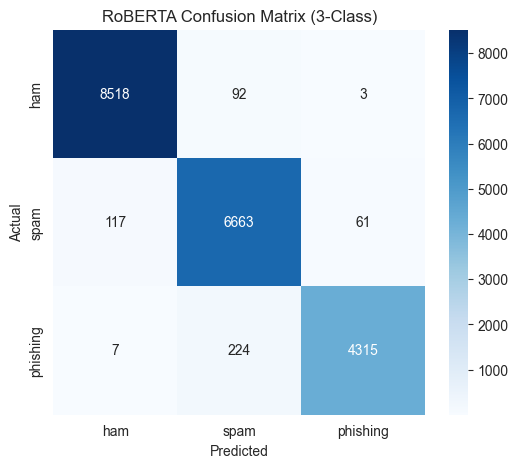


RoBERTA Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      8613
        spam       0.95      0.97      0.96      6841
    phishing       0.99      0.95      0.97      4546

    accuracy                           0.97     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.97      0.97     20000



In [29]:
cm_roberta = confusion_matrix(y_test_r, y_pred_roberta)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam', 'phishing'],
            yticklabels=['ham', 'spam', 'phishing'])
plt.title("RoBERTA Confusion Matrix (3-Class)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nRoBERTA Classification Report:")
print(classification_report(y_test_r, y_pred_roberta, target_names=["ham", "spam", "phishing"]))

## 5. Save Results
Save the evaluation results and combined dataset for later reference.

In [30]:
# Calculate RoBERTA metrics for saving
roberta_accuracy = accuracy_score(y_test_r, y_pred_roberta)
roberta_precision = precision_score(y_test_r, y_pred_roberta, average='weighted')
roberta_recall = recall_score(y_test_r, y_pred_roberta, average='weighted')
roberta_f1 = f1_score(y_test_r, y_pred_roberta, average='weighted')

# Save evaluation results for both models to JSON
results = {
    'naive_bayes': {
        'model': 'Naive Bayes (3-class)',
        'accuracy': round(nb_accuracy, 4),
        'precision': round(nb_precision, 4),
        'recall': round(nb_recall, 4),
        'f1_score': round(nb_f1, 4),
        'samples': len(X_test_text),
        'feature_count': len(FEATURE_COLS),
        'confusion_matrix': cm_nb.tolist(),
    },
    'roberta': {
        'model': 'RoBERTA with Phishing Features (3-class)',
        'accuracy': round(roberta_accuracy, 4),
        'precision': round(roberta_precision, 4),
        'recall': round(roberta_recall, 4),
        'f1_score': round(roberta_f1, 4),
        'samples': len(y_test_r),
        'num_phishing_features': len(feature_df.columns),
        'confusion_matrix': cm_roberta.tolist(),
    },
    'summary': {
        'total_dataset_samples': len(combined),
        'label_distribution': {0: int((y == 0).sum()), 1: int((y == 1).sum()), 2: int((y == 2).sum())},
    }
}

with open('../phishing_detection_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Also save model comparison
comparison = {
    'model_comparison': {
        'Naive Bayes Accuracy': round(nb_accuracy, 4),
        'RoBERTA Accuracy': round(roberta_accuracy, 4),
        'Best Model': 'RoBERTA' if roberta_accuracy >= nb_accuracy else 'Naive Bayes',
        'Accuracy Difference': round(abs(roberta_accuracy - nb_accuracy), 4)
    }
}

with open('../model_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)

# Save the combined dataset for reproducibility
combined.to_csv('../Dataset/combined_phishing.csv', index=False)

print('✓ Naive Bayes Results:')
print(f'  Accuracy: {round(nb_accuracy, 4)}, Precision: {round(nb_precision, 4)}, Recall: {round(nb_recall, 4)}, F1: {round(nb_f1, 4)}')
print('\n✓ RoBERTA Results:')
print(f'  Accuracy: {round(roberta_accuracy, 4)}, Precision: {round(roberta_precision, 4)}, Recall: {round(roberta_recall, 4)}, F1: {round(roberta_f1, 4)}')
print('\n✓ Files saved:')
print('  - ../phishing_detection_results.json (Both models)')
print('  - ../model_comparison.json (Model comparison)')
print('  - ../Dataset/combined_phishing.csv (Dataset)')
print('\n✓ Pipeline complete!')

✓ Naive Bayes Results:
  Accuracy: 0.97, Precision: 0.9701, Recall: 0.97, F1: 0.9699

✓ RoBERTA Results:
  Accuracy: 0.9748, Precision: 0.975, Recall: 0.9748, F1: 0.9748

✓ Files saved:
  - ../phishing_detection_results.json (Both models)
  - ../model_comparison.json (Model comparison)
  - ../Dataset/combined_phishing.csv (Dataset)

✓ Pipeline complete!
